In [3]:
import requests
import math

# 你之前验证过可用的基础配置
API_KEY = "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"

MODELS = [
    "meta-llama/llama-3.2-3b-instruct",
    "meta-llama/llama-3.1-8b-instruct",
    "qwen/qwen-2-7b-instruct",
    "mistralai/mistral-small",
    "qwen/qwen-2-32b-instruct",
    "mistralai/mistral-medium",
    "meta-llama/llama-3.3-70b-instruct",
    "qwen/qwen-2-72b-instruct",
    "openai/gpt-4o-mini",
    "openai/gpt-4o",
    "deepseek/deepseek-chat"
]

def probe_model(model_id):
    url = "https://openrouter.ai/api/v1/chat/completions"
    headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
    
    # 保持和你跑通的代码完全一致的 Payload 结构
    payload = {
        "model": model_id,
        "messages": [{"role": "user", "content": "A or B?"}],
        "logprobs": True,
        "top_logprobs": 5,
        "max_tokens": 1,
        "temperature": 0
    }
    
    try:
        response = requests.post(url, headers=headers, json=payload, timeout=15)
        data = response.json()
        
        if 'error' in data:
            return False, f"API Error: {data['error'].get('message')[:40]}"
        
        # 兼容性检查：尝试从不同路径读取 logprobs
        choice = data['choices'][0]
        lp_root = choice.get('logprobs')
        
        if lp_root:
            # 路径 A: content[0].top_logprobs (OpenAI 风格)
            content = lp_root.get('content')
            if content and len(content) > 0 and 'top_logprobs' in content[0]:
                return True, "Ready (Content Path)"
            
            # 路径 B: top_logprobs (部分开源 Provider 风格)
            if 'top_logprobs' in lp_root:
                return True, "Ready (Top-level Path)"
                
        return False, "No logprobs returned"
    except Exception as e:
        return False, f"Network Error: {str(e)[:40]}"

print("🔍 重新探测模型 Logprobs 真实支持情况...")
can_run = []
for m in MODELS:
    success, msg = probe_model(m)
    icon = "✅" if success else "❌"
    print(f"{icon} {m:40} | {msg}")
    if success: can_run.append(m)

print(f"\n🚀 探测完成！建议后续仅对以下模型运行全量脚本:\n{can_run}")

🔍 重新探测模型 Logprobs 真实支持情况...
❌ meta-llama/llama-3.2-3b-instruct         | No logprobs returned
❌ meta-llama/llama-3.1-8b-instruct         | No logprobs returned
❌ qwen/qwen-2-7b-instruct                  | API Error: No endpoints found for qwen/qwen-2-7b-in
❌ mistralai/mistral-small                  | API Error: No endpoints found for mistralai/mistral
❌ qwen/qwen-2-32b-instruct                 | API Error: qwen/qwen-2-32b-instruct is not a valid 
❌ mistralai/mistral-medium                 | API Error: No endpoints found for mistralai/mistral
❌ meta-llama/llama-3.3-70b-instruct        | No logprobs returned
❌ qwen/qwen-2-72b-instruct                 | API Error: No endpoints found for qwen/qwen-2-72b-i
✅ openai/gpt-4o-mini                       | Ready (Content Path)
✅ openai/gpt-4o                            | Ready (Content Path)
❌ deepseek/deepseek-chat                   | No logprobs returned

🚀 探测完成！建议后续仅对以下模型运行全量脚本:
['openai/gpt-4o-mini', 'openai/gpt-4o']


In [1]:
import pandas as pd
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RES_FOLDER = "res"
OUTPUT_FILE = "analysis_summary.csv"


def compute_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return acc, prec, rec, f1


def analyze_file(filepath):

    filename = os.path.basename(filepath)
    model_name = filename.replace("result_", "").replace(".csv", "")

    df = pd.read_csv(filepath)

    # 排序
    df = df.sort_values("original_index").reset_index(drop=True)

    # 只统计 success
    df = df[df["status"] == "success"]

    if df.empty:
        return None

    results = []

    # 构造二分类标签（A=1, B=0）
    y_true = (df["ground_truth"] == "A").astype(int)
    y_pred = (df["model_choice"] == "A").astype(int)

    # ===== overall =====
    acc, prec, rec, f1 = compute_metrics(y_true, y_pred)

    results.append({
        "model": model_name,
        "type": "OVERALL",
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "n_samples": len(df)
    })

    # ===== by type =====
    for t, group in df.groupby("type"):

        y_true = (group["ground_truth"] == "A").astype(int)
        y_pred = (group["model_choice"] == "A").astype(int)

        acc, prec, rec, f1 = compute_metrics(y_true, y_pred)

        results.append({
            "model": model_name,
            "type": t,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "n_samples": len(group)
        })

    return results


# ===== Jupyter 直接运行部分 =====

all_results = []

if not os.path.exists(RES_FOLDER):
    print("❌ res folder not found.")
else:
    for file in os.listdir(RES_FOLDER):
        if file.endswith(".csv"):
            filepath = os.path.join(RES_FOLDER, file)
            result = analyze_file(filepath)
            if result:
                all_results.extend(result)

    if not all_results:
        print("❌ No valid data found.")
    else:
        summary_df = pd.DataFrame(all_results)
        summary_df.to_csv(OUTPUT_FILE, index=False)
        summary_df


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Load Data
# =========================
df = pd.read_csv("analysis_summary.csv")
df["type"] = df["type"].str.strip()

# =========================
# 2. Overall Accuracy Bar Chart
# =========================
overall_df = df[df["type"] == "OVERALL"].copy()
overall_df = overall_df.sort_values("accuracy", ascending=False)

plt.figure()
plt.bar(overall_df["model"], overall_df["accuracy"])
plt.xticks(rotation=60)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy by Model")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("fig_overall_accuracy.png", dpi=300)
plt.close()


# =========================
# 3. LLaMA Scaling Curve
# =========================
param_map = {
    "meta-llama_llama-3.2-3b-instruct": 3,
    "meta-llama_llama-3.1-8b-instruct": 8,
    "meta-llama_llama-3.3-70b-instruct": 70,
}

scaling_df = overall_df[overall_df["model"].isin(param_map.keys())].copy()
scaling_df["params_B"] = scaling_df["model"].map(param_map)
scaling_df = scaling_df.sort_values("params_B")

plt.figure()
plt.plot(scaling_df["params_B"], scaling_df["accuracy"], marker="o")
plt.xscale("log")
plt.xlabel("Model Size (Billions of Parameters)")
plt.ylabel("Accuracy")
plt.title("LLaMA Scaling Trend")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("fig_llama_scaling.png", dpi=300)
plt.close()


# =========================
# 4. Type-wise Accuracy Heatmap
# =========================
type_df = df[df["type"] != "OVERALL"].copy()

pivot = type_df.pivot(index="model", columns="type", values="accuracy")

plt.figure()
plt.imshow(pivot, aspect="auto")
plt.colorbar()
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=60)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Accuracy by Type and Model")
plt.tight_layout()
plt.savefig("fig_type_heatmap.png", dpi=300)
plt.close()


# =========================
# 5. Per-Type Accuracy Comparison (Bar chart per type)
# =========================
for t in pivot.columns:
    subset = type_df[type_df["type"] == t].sort_values("accuracy", ascending=False)

    plt.figure()
    plt.bar(subset["model"], subset["accuracy"])
    plt.xticks(rotation=60)
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy on Type: {t}")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(f"fig_type_{t.replace(' ', '_')}.png", dpi=300)
    plt.close()


print("All figures saved successfully.")


All figures saved successfully.


--- 分析完成 ---
AUC: 1.0000
最优概率阈值: 0.6225


D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


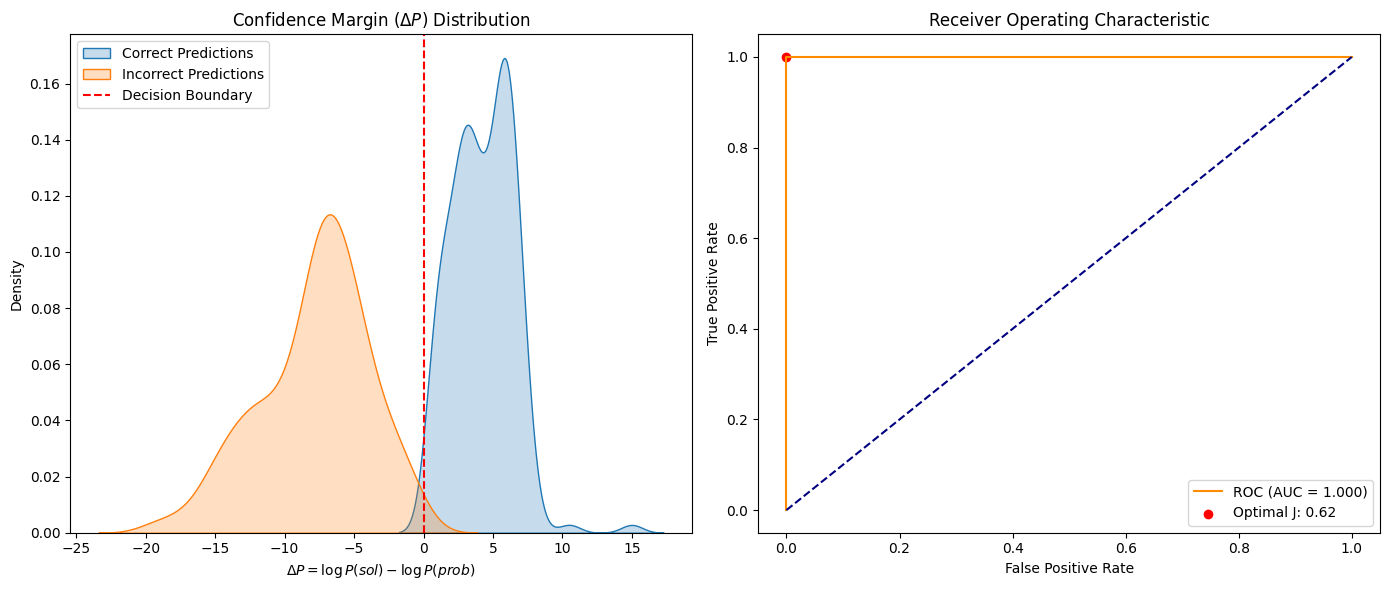

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# 1. 读取 Excel 文件 (直接读取 xlsx)
# 注意：文件名请根据你实际的文件名修改
file_name = '4omini-results.xlsx' 
df = pd.read_excel(file_name)

# 2. 概率处理与归一化 (Methodology Part 2 逻辑)
# 防止 p_sum 为 0，进行归一化
df['p_sum'] = df['p_solution'] + df['p_problem']
df['p_sol_norm'] = df['p_solution'] / df['p_sum']

# 计算 Delta P (Log-Scale)，加入 epsilon 防止 log(0)
eps = 1e-20
df['delta_p_log'] = np.log(df['p_solution'] + eps) - np.log(df['p_problem'] + eps)

# 3. ROC 曲线计算 (Methodology Part 3 逻辑)
fpr, tpr, thresholds = roc_curve(df['is_correct'], df['p_sol_norm'])
roc_auc = auc(fpr, tpr)

# 寻找最优阈值 (Youden's J statistic)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"--- 分析完成 ---")
print(f"AUC: {roc_auc:.4f}")
print(f"最优概率阈值: {best_threshold:.4f}")

# 4. 绘图：Delta P 分布与 ROC 曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 左图：概率边界分布 (证明梯度性质)
sns.kdeplot(data=df[df['is_correct']==1], x='delta_p_log', fill=True, label='Correct Predictions', ax=ax1)
sns.kdeplot(data=df[df['is_correct']==0], x='delta_p_log', fill=True, label='Incorrect Predictions', ax=ax1)
ax1.axvline(x=0, color='red', linestyle='--', label='Decision Boundary')
ax1.set_title('Confidence Margin ($\Delta P$) Distribution')
ax1.set_xlabel('$\Delta P = \log P(sol) - \log P(prob)$')
ax1.legend()

# 右图：ROC 曲线
ax2.plot(fpr, tpr, color='darkorange', label=f'ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Optimal J: {best_threshold:.2f}')
ax2.set_title('Receiver Operating Characteristic')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()

plt.tight_layout()
plt.savefig('result_plots.png', dpi=300)
plt.show()